# Final Model Training and Temporal Holdout Evaluation

The after-departure XGBoost configuration was selected using the 2019–2021 training period and the 2022 validation period.

In this notebook, the selected pipeline is retrained using all development data from 2019 through 2022. The frozen model is then scored against the January–August 2023 temporal holdout.

The 2023 holdout was not used for:

- model fitting
- hyperparameter tuning
- threshold selection
- model comparison

The target defines a delayed flight as an arrival delay of **15 minutes or more**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    TargetEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

In [2]:
from pathlib import Path


def find_project_root() -> Path:
    """
    Locate the project root whether the notebook is launched
    from the project root or from inside the notebooks folder.
    """
    current_path = Path.cwd().resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run this notebook from inside the "
        "Flight_Delay_Prediction project folder."
    )


PROJECT_ROOT = find_project_root()

RAW_DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
MODELS_DIRECTORY = PROJECT_ROOT / "models"

RAW_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/omarzakzook/Desktop/Flight_Delay_Prediction


In [3]:
engineered_data_path = (
    PROCESSED_DATA_DIRECTORY
    / "engineered_flight_data.csv"
)

df = pd.read_csv(
    engineered_data_path,
    parse_dates=["FL_DATE"]
)

print("Loaded from:", engineered_data_path)
print("Dataset shape:", df.shape)
df.head()

Loaded from: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/data/processed/engineered_flight_data.csv
Dataset shape: (2913802, 30)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DAY_OF_WEEK,QUARTER,IS_WEEKEND,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,ROUTE,IS_PEAK_SEASON,IS_BUSY_HOUR
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,Wednesday,1,0,11,Morning,Winter,Medium,FLL_EWR,0,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,Saturday,4,1,21,Night,Autumn,Medium,MSP_SEA,1,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,Friday,3,0,9,Morning,Summer,Medium,DEN_MSP,1,1
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,Monday,1,0,16,Afternoon,Spring,Long,MSP_SFO,0,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,Sunday,1,1,18,Evening,Winter,Medium,MCO_DFW,0,1


## Final Feature Set

The final model predicts arrival delay immediately after departure.

Therefore, the feature set includes actual departure information:

- `DEP_TIME`
- `DEP_DELAY`

Arrival-related variables, post-arrival variables, and delay-cause variables remain excluded to prevent target leakage.

In [4]:
selected_features = [
    "AIRLINE",
    "ORIGIN",
    "DEST",

    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",

    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",

    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "QUARTER",

    "DEP_HOUR",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY",

    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"
]

target = "IS_DELAYED"

print("Number of selected features:", len(selected_features))

Number of selected features: 21


## Final Chronological Split

The final development dataset combines observations from 2019 through 2022.

The January–August 2023 period is retained as the temporal holdout. Its labels are used only when the frozen final model is evaluated in this notebook.

In [5]:
final_train_df = df[
    df["YEAR"] <= 2022
].copy()

test_df = df[
    df["YEAR"] == 2023
].copy()

In [6]:
X_final_train = final_train_df[selected_features]
y_final_train = final_train_df[target]

X_test = test_df[selected_features]
y_test = test_df[target]

In [7]:
final_split_summary = pd.DataFrame({
    "Dataset": [
        "Final Training",
        "Temporal Holdout Test"
    ],
    "Period": [
        "2019–2022",
        "January–August 2023"
    ],
    "Rows": [
        len(X_final_train),
        len(X_test)
    ]
})

display(final_split_summary)

final_training_target_summary = pd.DataFrame({
    "Count": (
        y_final_train
        .value_counts()
        .sort_index()
    ),
    "Percentage (%)": (
        y_final_train
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

final_training_target_summary.index = [
    "On Time (<15 min)",
    "Delayed (≥15 min)"
]

display(final_training_target_summary)

,Dataset,Period,Rows
0,Final Training,2019–2022,2459389
1,Temporal Holdout Test,January–August 2023,454413


,Count,Percentage (%)
On Time (<15 min),2030185,82.55
Delayed (≥15 min),429204,17.45


In [8]:
numerical_features = [
    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "YEAR",
    "MONTH",
    "DAY",
    "QUARTER",
    "DEP_HOUR",
    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"
]

one_hot_features = [
    "DAY_OF_WEEK",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY"
]

target_encode_features = [
    "AIRLINE",
    "ORIGIN",
    "DEST"
]

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

one_hot_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

target_transformer = Pipeline(
    steps=[
        (
            "target_encoder",
            TargetEncoder(
                target_type="binary",
                random_state=42
            )
        )
    ]
)

In [10]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "onehot",
            one_hot_transformer,
            one_hot_features
        ),
        (
            "target",
            target_transformer,
            target_encode_features
        )
    ],
    remainder="drop"
)

In [11]:
final_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

In [12]:
print("Training the final XGBoost model...")

final_xgb_pipeline.fit(
    X_final_train,
    y_final_train
)

print("Final model training completed.")

Training the final XGBoost model...


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Final model training completed.


In [13]:
y_test_pred = final_xgb_pipeline.predict(
    X_test
)

y_test_prob = final_xgb_pipeline.predict_proba(
    X_test
)[:, 1]

In [14]:
final_test_results = {
    "Model": "Final After-Departure XGBoost",
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred
    ),
    "Precision": precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_test_prob
    )
}

pd.DataFrame(
    [final_test_results]
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Final After-Departure XGBoost,0.922401,0.920736,0.725537,0.811564,0.934201


In [15]:
print("Final Test Classification Report\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "On Time",
            "Delayed"
        ],
        zero_division=0
    )
)

Final Test Classification Report

              precision    recall  f1-score   support

     On Time       0.92      0.98      0.95    349754
     Delayed       0.92      0.73      0.81    104659

    accuracy                           0.92    454413
   macro avg       0.92      0.85      0.88    454413
weighted avg       0.92      0.92      0.92    454413



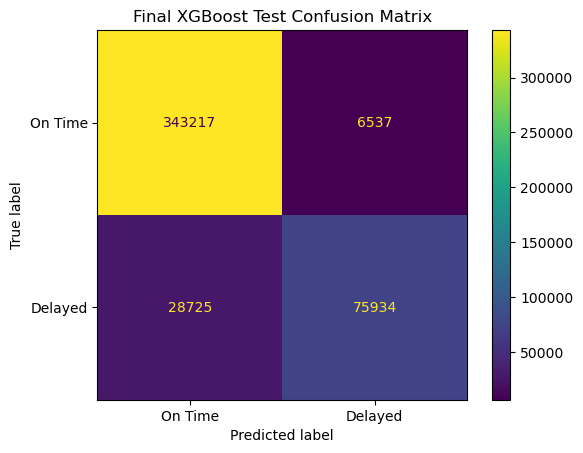

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "On Time",
        "Delayed"
    ]
)

plt.title(
    "Final XGBoost Test Confusion Matrix"
)

plt.show()

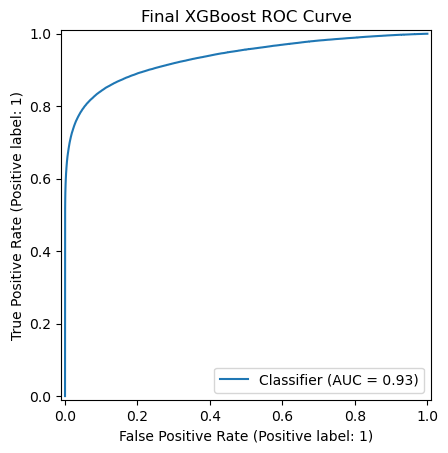

In [17]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title(
    "Final XGBoost ROC Curve"
)

plt.show()

In [18]:
models_directory = MODELS_DIRECTORY

models_directory.mkdir(
    parents=True,
    exist_ok=True
)

print("Models directory:")
print(models_directory)

Models directory:
/Users/omarzakzook/Desktop/Flight_Delay_Prediction/models


In [19]:
model_path = (
    models_directory
    / "final_after_departure_xgboost_pipeline.joblib"
)

joblib.dump(
    final_xgb_pipeline,
    model_path
)

print(
    f"Final model saved to: {models_directory}"
)

Final model saved to: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/models


In [20]:
results_path = (
    models_directory
    / "final_test_metrics.csv"
)

pd.DataFrame(
    [final_test_results]
).to_csv(
    results_path,
    index=False
)

print(
    f"Final metrics saved to: {results_path}"
)


Final metrics saved to: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/models/final_test_metrics.csv


## Final Temporal Holdout Results

The final model metrics, classification report, confusion matrix, ROC curve, and precision-recall curve are displayed above.

These results measure how the frozen after-departure pipeline performs on the January–August 2023 temporal holdout.

The model relies on actual departure information, particularly `DEP_DELAY`. Therefore, it must be interpreted as an after-departure arrival-delay model and not as a pre-departure warning system.

The output from this notebook is the authoritative source for the final test metrics used by the README and Streamlit application.

In [21]:
validation_test_comparison = pd.DataFrame([
    {
        "Dataset": "Validation",
        "Period": "2022",
        "Accuracy": 0.928082,
        "Precision": 0.920690,
        "Recall": 0.720150,
        "F1": 0.808165,
        "ROC_AUC": 0.933528
    },
    {
        "Dataset": "Temporal Holdout Test",
        "Period": "January–August 2023",
        "Accuracy": final_test_results["Accuracy"],
        "Precision": final_test_results["Precision"],
        "Recall": final_test_results["Recall"],
        "F1": final_test_results["F1"],
        "ROC_AUC": final_test_results["ROC_AUC"]
    }
])

validation_test_comparison

,Dataset,Period,Accuracy,Precision,Recall,F1,ROC_AUC
0,Validation,2022,0.928082,0.920690,0.720150,0.808165,0.933528
1,Temporal Holdout Test,January–August 2023,0.922401,0.920736,0.725537,0.811564,0.934201


## Final Conclusion

The project first evaluated models using scheduled-flight, airport, airline, calendar, and seasonal information available before departure.

The corrected pre-departure experiments showed limited predictive performance. Temporal hyperparameter tuning produced only a negligible F1 improvement, indicating that parameter optimization alone could not overcome the limited signal in the available pre-departure variables.

The operational scenario was then changed to predict arrival delay immediately after departure. At this point, `DEP_TIME` and `DEP_DELAY` become available.

The after-departure XGBoost pipeline produced substantially stronger validation performance and was selected as the final configuration. It was retrained using data from 2019 through 2022 and scored against the January–August 2023 temporal holdout.

The final system must be described specifically as an **after-departure arrival-delay prediction model**. Its main limitation is that it cannot provide a prediction before the aircraft has departed.

## Save Deployment Metadata

The Streamlit application requires valid airline and airport options. These values are extracted from the final training dataset and saved separately so the application does not need to load the complete flight dataset.

In [22]:
import hashlib
import platform

from importlib.metadata import version


model_sha256 = hashlib.sha256(
    model_path.read_bytes()
).hexdigest()

deployment_metadata = {
    "artifact_version": "2.0",
    "model_file": model_path.name,
    "model_sha256": model_sha256,

    "prediction_moment": (
        "immediately_after_departure"
    ),

    "target_definition": (
        "IS_DELAYED = 1 when ARR_DELAY >= 15 minutes"
    ),

    "class_labels": {
        0: "On Time (<15 min)",
        1: "Delayed (>=15 min)"
    },

    "decision_threshold": 0.5,
    "probability_calibrated": False,

    "training_period": (
        "2019-01-01 through 2022-12-31"
    ),

    "test_period": (
        "2023-01-01 through 2023-08-31"
    ),

    "training_scope": (
        "Completed, non-diverted flights only"
    ),

    "feature_names": selected_features,

    "package_versions": {
        "python": platform.python_version(),
        "pandas": version("pandas"),
        "numpy": version("numpy"),
        "scikit-learn": version("scikit-learn"),
        "xgboost": version("xgboost"),
        "joblib": version("joblib")
    },

    "validation_metrics": {
        "Accuracy": 0.928082,
        "Precision": 0.920690,
        "Recall": 0.720150,
        "F1": 0.808165,
        "ROC_AUC": 0.933528
    },

    "test_metrics": {
        key: value
        for key, value in final_test_results.items()
        if key != "Model"
    },

    "airlines": sorted(
        X_final_train["AIRLINE"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),

    "origins": sorted(
        X_final_train["ORIGIN"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),

    "destinations": sorted(
        X_final_train["DEST"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),

    "defaults": {
        "CRS_ELAPSED_TIME": float(
            X_final_train[
                "CRS_ELAPSED_TIME"
            ].median()
        ),

        "DISTANCE": float(
            X_final_train[
                "DISTANCE"
            ].median()
        )
    }
}

In [23]:
metadata_path = (
    models_directory
    / "deployment_metadata.joblib"
)

joblib.dump(
    deployment_metadata,
    metadata_path
)

print(f"Deployment metadata saved to: {metadata_path}")

Deployment metadata saved to: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/models/deployment_metadata.joblib


In [24]:
print("Artifact version:")
print(deployment_metadata["artifact_version"])

print("\nPrediction moment:")
print(deployment_metadata["prediction_moment"])

print("\nTarget definition:")
print(deployment_metadata["target_definition"])

print("\nFeature count:")
print(len(deployment_metadata["feature_names"]))

print("\nAirlines:")
print(len(deployment_metadata["airlines"]))

print("\nOrigin airports:")
print(len(deployment_metadata["origins"]))

print("\nDestination airports:")
print(len(deployment_metadata["destinations"]))

print("\nModel SHA-256:")
print(deployment_metadata["model_sha256"])

print("\nPackage versions:")
print(deployment_metadata["package_versions"])

Artifact version:
2.0

Prediction moment:
immediately_after_departure

Target definition:
IS_DELAYED = 1 when ARR_DELAY >= 15 minutes

Feature count:
21

Airlines:
18

Origin airports:
380

Destination airports:
380

Model SHA-256:
31f57e11f7a29395c460e4280a46c6a3ebd94583aea5a5b1486faa9bd95b0bd1

Package versions:
{'python': '3.11.14', 'pandas': '2.3.3', 'numpy': '2.3.5', 'scikit-learn': '1.9.0', 'xgboost': '3.2.0', 'joblib': '1.5.3'}
